In [2]:
import pandas as pd
import os

In [3]:
cwd= os.getcwd()
print(cwd)
BASE_DIR= os.path.join(cwd,"..")

data= os.path.join(BASE_DIR, "data", "concat_for_eda.csv")

/home/hngoc/thesis/microcytic-reduced/notebooks


In [4]:
df= pd.read_csv(data)
# df= pd.read_excel(data)
print(df)
print(df.shape)

        Hb   MCV   Fe  Ferritin  Transferin   TSAT (%)    CRP Chẩn đoán  \
0     86.0  76.6  3.1   1062.00       170.0   2.852014  174.8  ACD, IDA   
1    114.0  78.5  2.2    457.00       145.0   8.476209   15.3       ACD   
2     84.0  75.5  2.6    445.30        93.0  15.618430  120.1       ACD   
3    115.0  79.6  1.7   1151.00       125.0   7.597765    9.9       ACD   
4     90.0  57.3  2.9   2009.00       116.0  13.966480   62.9       ACD   
..     ...   ...  ...       ...         ...        ...    ...       ...   
96    87.0  61.1  2.0       NaN         NaN        NaN    NaN  ACD, IDA   
97   100.0  70.2  3.0       NaN         NaN        NaN    NaN       IDA   
98    84.0  55.8  NaN      2.75         NaN        NaN    NaN       IDA   
99    66.0  60.4  NaN       NaN         NaN        NaN    NaN       IDA   
100   77.0  58.3  NaN       NaN         NaN        NaN    NaN       IDA   

     Tiền sử hoặc bệnh kèm theo  Tuổi  ...  Hb khác  Đột biến gen thalassemia  \
0                 

In [ ]:
df.info()

### Univariable Distribution

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_copy= df.copy()

X_y_don= df_copy.drop(columns= ["ACD", "IDA", "Thal"])


In [ ]:
null_X = X_y_don.drop(columns= ["Chẩn đoán"])
null_counts = null_X.isnull().sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar')

# Xoay trục x 45 độ
plt.xticks(rotation=80)

plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Nulls')

plt.tight_layout()
plt.show()

In [ ]:
for i in range(len(X_y_don)):
    col_name= X_y_don.columns[i]
    plt.figure()
    sns.boxplot(data= X_y_don, x=col_name, hue= "Chẩn đoán")
    plt.legend(
    title= f"Univariable distribution of {col_name} following diagnoses",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
    plt.show()

In [ ]:
"""
df["Decision_Class_Label"] = df["Decision_Class"].map({0: "healthy", 1: "anemia"})
sns.countplot(data=df, x="Decision_Class_Label")
plt.xlabel("Diagnosis")
plt.ylabel("Samples")
"""

In [ ]:
plt.figure()
sns.countplot(data= X_y_don, x= "Giới_Nữ", hue= "Chẩn đoán")
plt.legend(
    title= "Univariable distribution of gender following diagnoses",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)

In [ ]:
# làm cái này với điều kiện no null values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_y_don.drop("Chẩn đoán", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_y_don["Chẩn đoán"])

In [ ]:
from sklearn.manifold import TSNE

X = df.drop("Diagnosis", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

plt.figure()
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=df["Diagnosis"])
plt.legend(
    title="Diagnosis",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_embedded, df["Diagnosis"])
print(score)

In [ ]:
plt.figure()

ax = sns.kdeplot(
    x=X_embedded[:,0],
    y=X_embedded[:,1],
    hue=df["Diagnosis"]
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=clusters)

In [ ]:
df.groupby("Diagnosis")["LYMp"].describe()

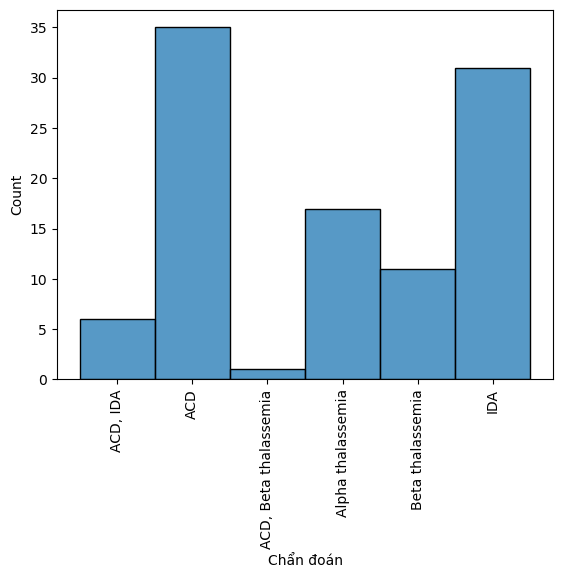

In [6]:
#sns.histplot(cleaned_df["Chẩn đoán (chỉ liên quan hồng cầu nhỏ: IDA, ACD, Thalassemia, CRNN)"])
sns.histplot(df["Chẩn đoán"])
plt.xticks(rotation=90)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

"""
def combine_images(img_paths):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, img_path in zip(axes, img_paths):
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis("off")  # tắt trục cho đẹp

    return fig
"""
save_dir= os.path.join(BASE_DIR, "notebooks", "png")
pr_paths= [os.path.join(save_dir, "pr_curve_rf.png"), os.path.join(save_dir, "pr_curve_xgb.png"), os.path.join(save_dir, "pr_curve_lgbm.png")]
roc_paths= [os.path.join(save_dir, "roc_auc_rf.png"), os.path.join(save_dir, "roc_auc_xgb.png"), os.path.join(save_dir, "roc_auc_lgbm.png")]



In [ ]:
#combined_pr_fig = combine_images(pr_paths)


In [ ]:
#combined_roc_fig = combine_images(roc_paths)

In [ ]:
    
data_shap= os.path.join(BASE_DIR, "data", "test_data.csv")

df_shap= pd.read_csv(data_shap)

X = df_shap.drop(columns=["ACD", "IDA", "Thal"])
y = df_shap[["ACD", "IDA", "Thal"]]


In [ ]:
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import joblib

def plot_multi_roc(models_dict, y_true, X_test):
    labels = y_true.columns.tolist()  # ["ACD", "IDA", "Thal"]
    
    figs = {}

    for i, label in enumerate(labels):
        fig, ax = plt.subplots()

        for name, path in models_dict.items():
            model = joblib.load(path)
            y_probs = model.predict_proba(X_test)

            y_prob = y_probs[i][:, 1]   # lấy class 1 của label i
            y_true_label = y_true.iloc[:, i]

            fpr, tpr, _ = roc_curve(y_true_label, y_prob)
            roc_auc = auc(fpr, tpr)

            ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(f"ROC Curve - {label}")
        ax.legend()

        figs[label] = fig

    return figs


from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multi_pr(models_dict, y_true, X_test):
    labels = y_true.columns.tolist()
    
    figs = {}

    for i, label in enumerate(labels):
        fig, ax = plt.subplots()

        for name, path in models_dict.items():
            model = joblib.load(path)
            y_probs = model.predict_proba(X_test)

            y_prob = y_probs[i][:, 1]
            y_true_label = y_true.iloc[:, i]

            precision, recall, _ = precision_recall_curve(y_true_label, y_prob)
            ap = average_precision_score(y_true_label, y_prob)

            ax.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"PR Curve - {label}")
        ax.legend()

        figs[label] = fig

    return figs

In [ ]:
models = {
    "RF": os.path.join(BASE_DIR, "artifacts", "RF_best_model.pkl"),
    "XGBoost": os.path.join(BASE_DIR, "artifacts", "XGBoost_best_model.pkl"),
    "LightGBM": os.path.join(BASE_DIR, "artifacts", "LightGBM_best_model.pkl")
}

fig_roc = plot_multi_roc(models, y, X)
fig_pr = plot_multi_pr(models, y, X)

In [ ]:
fig_pr = plot_multi_pr(models, y, X)
display(fig_pr)

In [ ]:
fig_roc = plot_multi_roc(models, y, X)
display(fig_roc)

In [6]:
y = df[["ACD", "IDA", "Alpha thalassemia" ,"Beta thalassemia"]]

counts = y.value_counts()

print(counts)

ACD  IDA  Alpha thalassemia  Beta thalassemia
1    0    0                  0                   35
0    1    0                  0                   31
     0    1                  0                   17
          0                  1                   11
1    1    0                  0                    6
     0    0                  1                    1
Name: count, dtype: int64


In [7]:
import pandas as pd

# Các nhãn
labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]

# Ma trận đồng xuất hiện
co_matrix = pd.DataFrame(
    0,
    index=labels,
    columns=labels
)

# Đếm số lần xuất hiện cùng nhau
for _, row in y.iterrows():

    active_labels = row[row == 1].index.tolist()

    for l1 in active_labels:
        for l2 in active_labels:
            co_matrix.loc[l1, l2] += 1

print(co_matrix)

                   ACD  IDA  Alpha thalassemia  Beta thalassemia
ACD                 42    6                  0                 1
IDA                  6   37                  0                 0
Alpha thalassemia    0    0                 17                 0
Beta thalassemia     1    0                  0                12
